# 🔧 02 - Feature Engineering
## AMEEMAW: AI Mamma-Echography Educator & Empathetic Mentor for Awareness & Wellness

**Author:** Shira Amina Ortiz Olivares 🐧  
**Date:** December 2025  
**Dataset:** Breast Ultrasound Images (BUSI)

---

### 🐧 Welcome to Feature Engineering!

Now that we know our data (thanks EDA!), it's time to prepare it for modeling.

**What we'll do:**
1. 📂 Load our metadata from EDA
2. ✂️ Create train/val/test splits (stratified!)
3. 🖼️ Build image preprocessing pipeline
4. 🔄 Set up data augmentation
5. ⚖️ Handle class imbalance (weights + weighted sampling)
6. 📊 Extract radiomics features from masks
7. 💾 Save everything for model training

Let's get this done!

---

## 1. 🔧 Environment Setup

In [ ]:
# ============================================
# ENVIRONMENT SETUP
# ============================================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🐧 Running in Google Colab!")
    print("📦 Installing packages (this takes ~2 min)...\n")

    # Install SimpleITK
    !pip install -q SimpleITK

    # Install pyradiomics from source (works with newer numpy)                  # Took me time to figure this out. May produce some warnings, but so far so good, at least for this notebook. :)
    !pip install -q git+https://github.com/AIM-Harvard/pyradiomics.git

    # Create directories
    !mkdir -p /content/reports/figures /content/data/processed /content/models

    print("\n✅ Colab setup complete!")
    print("💡 Make sure Dataset_BUSI_with_GT is uploaded!")
else:
    print("💻 Running locally")

🐧 Running in Google Colab!
📦 Installing packages (this takes ~2 min)...

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 44.9 MB/s eta 0:00:00

✅ Colab setup complete!
💡 Make sure Dataset_BUSI_with_GT is uploaded!


## 2. 📚 Imports

In [ ]:
# ============================================
# IMPORTS
# ============================================

import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Image processing
import cv2
from PIL import Image

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Radiomics
from radiomics import featureextractor
import SimpleITK as sitk

print("✅ All imports successful!")
print("✅ Radiomics available!")
print(f"🐧 PyTorch version: {torch.__version__}")
print(f"🖥️ CUDA available: {torch.cuda.is_available()}")

✅ All imports successful!
✅ Radiomics available!
🐧 PyTorch version: 2.9.0+cu126
🖥️ CUDA available: True


## 3. 📂 Path Configuration & Load Data

In [ ]:
# ============================================
# PATHS
# ============================================

if IN_COLAB:
    !unzip -q /content/Dataset_BUSI_with_GT.zip -d /content/                        # uncomment this is you uploaded a ZIP version
    DATA_DIR = Path("/content/Dataset_BUSI_with_GT")
    PROJECT_ROOT = Path("/content")
else:
    PROJECT_ROOT = Path.cwd().parent
    DATA_DIR = PROJECT_ROOT / "data" / "raw" / "Dataset_BUSI_with_GT"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

print("📂 Paths configured")
print(f"   Data: {DATA_DIR}")
print(f"   Processed: {PROCESSED_DIR}")

📂 Paths configured
   Data: /content/Dataset_BUSI_with_GT
   Processed: /content/data/processed


In [ ]:
# ============================================
# LOAD METADATA FROM EDA
# ============================================

metadata_path = PROCESSED_DIR / 'image_metadata.csv'

if metadata_path.exists():
    df = pd.read_csv(metadata_path)
    print(f"✅ Loaded metadata: {len(df)} images")
else:
    print("❌ Metadata not found! Recreating...")

    # Quick recreation if needed
    records = []
    for cls in ['normal', 'benign', 'malignant']:
        class_dir = DATA_DIR / cls
        for f in class_dir.glob("*.png"):
            if '_mask' not in f.name:
                mask_path = class_dir / f"{f.stem}_mask.png"
                records.append({
                    'image_path': str(f),
                    'mask_path': str(mask_path) if mask_path.exists() else None,
                    'class': cls,
                    'has_mask': mask_path.exists()
                })
    df = pd.DataFrame(records)
    df['class_encoded'] = df['class'].map({'normal': 0, 'benign': 1, 'malignant': 2})
    print(f"✅ Recreated metadata: {len(df)} images")

print(f"\n🐧 Dataset overview:")
print(df['class'].value_counts())
df.head()

✅ Loaded metadata: 780 images

🐧 Dataset overview:
class
benign       437
malignant    210
normal       133
Name: count, dtype: int64


,image_path,mask_path,class,has_mask,mask_count,filename,class_encoded,height,width,aspect_ratio,mean_intensity,std_intensity,min_intensity,max_intensity,lesion_area,lesion_ratio
0,/content/Dataset_BUSI_with_GT/normal/normal (3...,/content/Dataset_BUSI_with_GT/normal/normal (3...,normal,True,1,normal (31).png,0,473,547,1.156448,88.956271,62.339838,0,255,0.0,0.0
1,/content/Dataset_BUSI_with_GT/normal/normal (1...,/content/Dataset_BUSI_with_GT/normal/normal (1...,normal,True,1,normal (100).png,0,574,690,1.202091,60.309478,33.816918,0,241,0.0,0.0
2,/content/Dataset_BUSI_with_GT/normal/normal (8...,/content/Dataset_BUSI_with_GT/normal/normal (8...,normal,True,1,normal (82).png,0,468,560,1.196581,86.678751,58.195398,0,255,0.0,0.0
3,/content/Dataset_BUSI_with_GT/normal/normal (8...,/content/Dataset_BUSI_with_GT/normal/normal (8...,normal,True,1,normal (88).png,0,463,560,1.209503,48.149360,43.660827,0,241,0.0,0.0
4,/content/Dataset_BUSI_with_GT/normal/normal (7...,/content/Dataset_BUSI_with_GT/normal/normal (7...,normal,True,1,normal (70).png,0,471,557,1.182590,87.893385,43.471589,0,255,0.0,0.0


---

## 4. ✂️ Train/Validation/Test Split

🐧 This is crucial! We need to:
- Split data into **train (70%)**, **val (15%)**, **test (15%)**
- Use **stratified** splitting to maintain class proportions
- Set a **random seed** for reproducibility

💡 Never touch the test set until final evaluation!

In [ ]:
# ============================================
# STRATIFIED TRAIN/VAL/TEST SPLIT
# 70% train, 15% val, 15% test
# ============================================

RANDOM_SEED = 42                                               # yes, 42 wins for now!

# First split: 70% train, 30% temp (will become val + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['class'],  # Maintain class proportions!
    random_state=RANDOM_SEED
)

# Second split: 50% of temp = 15% val, 50% of temp = 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['class'],
    random_state=RANDOM_SEED
)

# Add split labels
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

print("🐧 DATA SPLITS")
print("=" * 40)
print(f"Train: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} images")

🐧 DATA SPLITS
Train: 546 images (70.0%)
Val:   117 images (15.0%)
Test:  117 images (15.0%)
Total: 780 images


In [ ]:
# ============================================
# VERIFY STRATIFICATION
# Class proportions should be similar across splits
# ============================================

print("🐧 CLASS DISTRIBUTION BY SPLIT")
print("=" * 50)

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{split_name}:")
    counts = split_df['class'].value_counts()
    for cls in ['normal', 'benign', 'malignant']:
        pct = counts[cls] / len(split_df) * 100
        print(f"  {cls.capitalize():<10} {counts[cls]:>3} ({pct:.1f}%)")

🐧 CLASS DISTRIBUTION BY SPLIT

Train:
  Normal      93 (17.0%)
  Benign     306 (56.0%)
  Malignant  147 (26.9%)

Val:
  Normal      20 (17.1%)
  Benign      65 (55.6%)
  Malignant   32 (27.4%)

Test:
  Normal      20 (17.1%)
  Benign      66 (56.4%)
  Malignant   31 (26.5%)


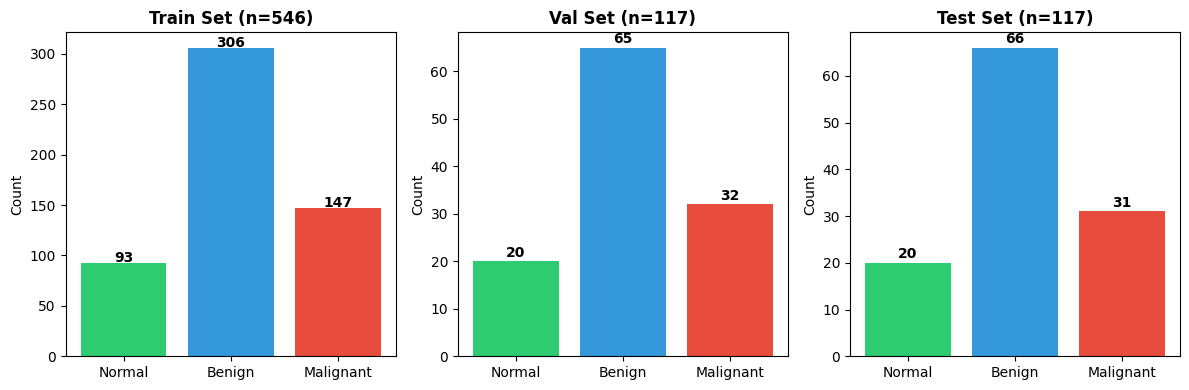

📊 Saved: data_splits.png


In [ ]:
# ============================================
# VISUALIZE SPLITS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['#2ecc71', '#3498db', '#e74c3c']

for ax, (name, split_df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = [split_df[split_df['class'] == c].shape[0] for c in ['normal', 'benign', 'malignant']]
    ax.bar(['Normal', 'Benign', 'Malignant'], counts, color=colors)
    ax.set_title(f'{name} Set (n={len(split_df)})', fontweight='bold')
    ax.set_ylabel('Count')
    for i, c in enumerate(counts):
        ax.text(i, c + 1, str(c), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'data_splits.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: data_splits.png")

### 🐧💡 Insight: Stratification Success!

Notice how each split has roughly the same class proportions (~17% Normal, ~56% Benign, ~27% Malignant). This is crucial because:

1. **Training** sees representative samples of all classes
2. **Validation** gives us reliable performance estimates
3. **Test** will be a fair final evaluation

Without stratification, we might accidentally put all Normal images in one split!

In [ ]:
# ============================================
# COMBINE AND SAVE SPLIT DATAFRAMES
# ============================================

# Combine all with split labels
df_all = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Save individual splits
train_df.to_csv(PROCESSED_DIR / 'train.csv', index=False)
val_df.to_csv(PROCESSED_DIR / 'val.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test.csv', index=False)

# Save combined with split column
df_all.to_csv(PROCESSED_DIR / 'all_splits.csv', index=False)

print("💾 Saved split files:")
print("   • train.csv")
print("   • val.csv")
print("   • test.csv")
print("   • all_splits.csv")

💾 Saved split files:
   • train.csv
   • val.csv
   • test.csv
   • all_splits.csv


---

## 5. 🖼️ Image Preprocessing Pipeline

🐧 CNNs need consistent input! We'll:
- Resize all images to **224x224** (standard for pretrained models)
- Convert grayscale to **3-channel RGB** (pretrained models expect this)
- Normalize using **ImageNet statistics**

💡 ImageNet normalization: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

#### 🐧💡 Why ImageNet Normalization?  

We use ImageNet statistics (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) because:
  
1. Transfer learning — the pretrained models (EfficientNet, ResNet, etc.) were trained on ImageNet with these exact values  
2. Same scale — The model expects inputs normalized this way; using different stats would confuse it  
3. Better convergence — Matching the original training distribution helps the model learn faster  

Think of it like speaking the same language — if the model learned on ImageNet-normalized images, we should "speak" to it the same way! 🗣️ Kumusta!

In [ ]:
# ============================================
# PREPROCESSING CONSTANTS
# ============================================

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("🐧 PREPROCESSING CONFIG")
print("=" * 40)
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Normalization: ImageNet stats")
print(f"  Mean: {IMAGENET_MEAN}")
print(f"  Std:  {IMAGENET_STD}")

🐧 PREPROCESSING CONFIG
Image size: 224x224
Normalization: ImageNet stats
  Mean: [0.485, 0.456, 0.406]
  Std:  [0.229, 0.224, 0.225]


In [ ]:
# ============================================
# TRANSFORM PIPELINES
# Different transforms for train vs val/test
# ============================================

# Training: With augmentation to increase variety
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),      # Resize to 224x224
    transforms.RandomHorizontalFlip(p=0.5),       # Flip left-right randomly
    transforms.RandomVerticalFlip(p=0.5),         # Flip up-down randomly
    transforms.RandomRotation(degrees=15),        # Rotate ±15 degrees - 15° is a commonly used value in medical imaging literature that balances augmentation variety with preserving clinically realistic orientations
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Vary brightness/contrast
    transforms.ToTensor(),                        # Convert to tensor [0,1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # Normalize
])

# Validation/Test: No augmentation - we want consistent evaluation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✅ Transform pipelines created!")
print("\n🔄 Training augmentations:")
print("   • Random horizontal flip (50%)")
print("   • Random vertical flip (50%)")
print("   • Random rotation (±15°)")
print("   • Color jitter (brightness/contrast)")

✅ Transform pipelines created!

🔄 Training augmentations:
   • Random horizontal flip (50%)
   • Random vertical flip (50%)
   • Random rotation (±15°)
   • Color jitter (brightness/contrast)


### 🐧💡 Why Data Augmentation?

We have a small dataset (780 images) with class imbalance. Augmentation helps by:

1. **Creating variety** — same image, different perspectives
2. **Reducing overfitting** — model sees "new" images each epoch
3. **Improving generalization** — learns rotation/flip invariant features

We only augment **training data** — val/test should reflect real-world conditions!

In [ ]:
# ============================================
# CUSTOM DATASET CLASS
# Loads images and applies transforms
# ============================================

class BUSIDataset(Dataset):
    """
    PyTorch Dataset for BUSI images.

    Handles:
    - Loading images from paths
    - Converting grayscale to RGB (pretrained models need 3 channels)
    - Applying transforms (augmentation, normalization)
    """

    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe: DataFrame with 'image_path' and 'class_encoded' columns
            transform: torchvision transforms to apply
        """
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image path and label
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = row['class_encoded']

        # Load image and convert grayscale to RGB
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

print("✅ BUSIDataset class defined!")

✅ BUSIDataset class defined!


In [ ]:
# ============================================
# CREATE DATASETS
# ============================================

train_dataset = BUSIDataset(train_df, transform=train_transforms)
val_dataset = BUSIDataset(val_df, transform=val_test_transforms)
test_dataset = BUSIDataset(test_df, transform=val_test_transforms)

print("🐧 DATASETS CREATED")
print("=" * 40)
print(f"Train: {len(train_dataset)} images (with augmentation)")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

🐧 DATASETS CREATED
Train: 546 images (with augmentation)
Val:   117 images
Test:  117 images


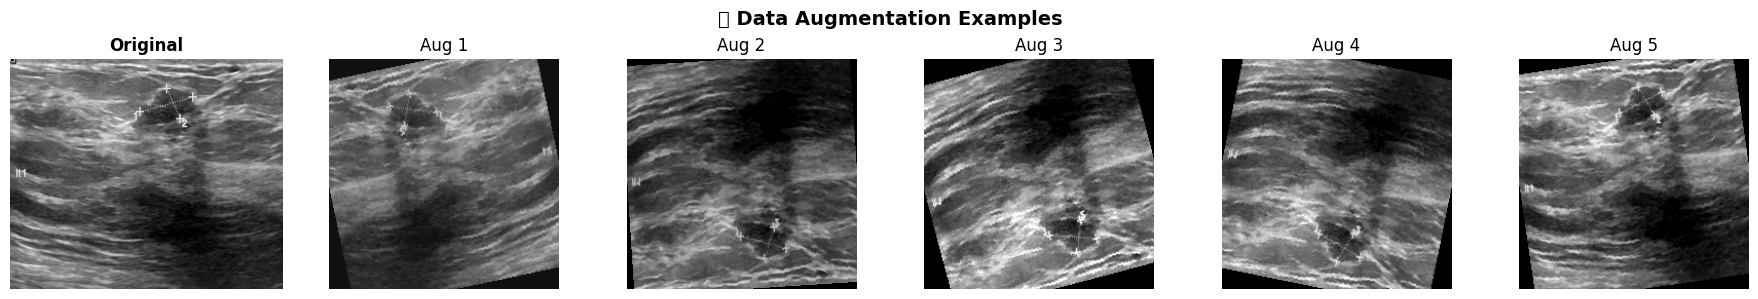

📊 Saved: augmentation_examples.png


In [ ]:
# ============================================
# VISUALIZE AUGMENTATIONS
# Let's see what augmented images look like!
# ============================================

def show_augmentations(dataset, idx=0, n_versions=5):
    """Show multiple augmented versions of the same image."""
    fig, axes = plt.subplots(1, n_versions + 1, figsize=(3*(n_versions+1), 3))

    # Original image (no transforms)
    orig_path = dataset.df.iloc[idx]['image_path']
    orig_img = Image.open(orig_path).convert('RGB')
    axes[0].imshow(orig_img)
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')

    # Augmented versions - each call gives different random augmentation
    for i in range(n_versions):
        img, _ = dataset[idx]
        # Denormalize for display
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        axes[i+1].imshow(img)
        axes[i+1].set_title(f'Aug {i+1}')
        axes[i+1].axis('off')

    plt.suptitle('🐧 Data Augmentation Examples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'augmentation_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

show_augmentations(train_dataset, idx=0)
print("📊 Saved: augmentation_examples.png")

---

## 6. ⚖️ Handling Class Imbalance

🐧 This is SUPER important! Our dataset has class imbalance:
- Normal: ~17% (minority)
- Benign: ~56% (majority)
- Malignant: ~27%

💡 Without handling this, our model might just predict "Benign" for everything and still get 56% accuracy!

---

### 🐧💡 Why WeightedRandomSampler? A Deep Dive

There are several ways to handle class imbalance. Let's compare them:

| Method | How it Works | Pros | Cons | Best For |
|--------|--------------|------|------|----------|
| **Class Weights** | Adjust loss function to penalize minority class errors more | Simple, no data changes | Model still sees imbalanced batches | Tabular data, smaller imbalance |
| **Undersampling** | Remove samples from majority class | Balanced batches | **Loses valuable data!** | When you have tons of data |
| **Oversampling (duplicate)** | Duplicate minority samples | More minority examples | Risk of overfitting to duplicates | Small datasets, simple |
| **SMOTE** | Generate synthetic samples | Creates variety | **Doesn't work for images!** | Tabular data only |
| **WeightedRandomSampler** ✅ | Sample minority classes more frequently | Balanced batches, uses ALL data, different combos each epoch | Slightly more complex | **Image classification!** |

### Why WeightedRandomSampler is Perfect for Us:

1. **No data loss** — We use ALL 780 images (unlike undersampling)
2. **Balanced batches** — Each batch has ~equal representation of all classes
3. **Natural augmentation** — Combined with our transforms, minority class sees MORE variety
4. **Works with images** — Unlike SMOTE which only works for tabular data
5. **Different combinations each epoch** — Reduces overfitting risk vs simple duplication

We'll use **BOTH** class weights (for loss) AND weighted sampling (for batches) — belt AND suspenders! 🎯

In [ ]:
# Augmentation + WeightedRandomSampler work together: minority class gets sampled more often,
# and each time it appears, random transforms make it look different — achieving variety
# without generating synthetic images (which don't work well for medical imaging)

In [ ]:
# ============================================
# COMPUTE CLASS WEIGHTS
# These will be used in the loss function
# Higher weight = more penalty for mistakes
# ============================================

# Compute weights based on training set only (not val/test!)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['class_encoded'].values
)

# Convert to tensor for PyTorch
class_weights_tensor = torch.FloatTensor(class_weights)

print("🐧 CLASS WEIGHTS (for loss function)")
print("=" * 45)
print(f"{'Class':<12} {'Count':>6} {'Weight':>10}")
print("-" * 45)
for cls_name, cls_id in [('Normal', 0), ('Benign', 1), ('Malignant', 2)]:
    count = (train_df['class_encoded'] == cls_id).sum()
    print(f"{cls_name:<12} {count:>6} {class_weights[cls_id]:>10.4f}")

print("\n💡 Interpretation:")
print(f"   Normal has {class_weights[0]/class_weights[1]:.1f}x higher weight than Benign")
print(f"   → Model is penalized {class_weights[0]/class_weights[1]:.1f}x more for misclassifying Normal!")

🐧 CLASS WEIGHTS (for loss function)
Class         Count     Weight
---------------------------------------------
Normal           93     1.9570
Benign          306     0.5948
Malignant       147     1.2381

💡 Interpretation:
   Normal has 3.3x higher weight than Benign
   → Model is penalized 3.3x more for misclassifying Normal!


In [ ]:
# ============================================
# CREATE WEIGHTED RANDOM SAMPLER
# This ensures balanced batches during training
# ============================================

# Step 1: Assign a weight to each SAMPLE (not class)
# Each sample gets the weight of its class
sample_weights = [class_weights[label] for label in train_df['class_encoded'].values]
sample_weights = torch.DoubleTensor(sample_weights)

# Step 2: Create the sampler
# - num_samples: how many samples per epoch (we use full dataset size)
# - replacement=True: allows sampling same image multiple times
#   (necessary because minority class would run out otherwise)
#   Combined with augmentation, each repeat looks different — so the model
#   sees varied versions rather than identical duplicates, reducing overfitting risk
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("🐧 WEIGHTED RANDOM SAMPLER CREATED")
print("=" * 45)
print(f"Total samples per epoch: {len(sample_weights)}")
print(f"Replacement: True (minority samples may repeat)")
print("\n💡 How it works:")
print("   → Normal images have HIGHER probability of being selected")
print("   → Each batch will have ~balanced class representation")
print("   → Model sees minority class more often!")

🐧 WEIGHTED RANDOM SAMPLER CREATED
Total samples per epoch: 546
Replacement: True (minority samples may repeat)

💡 How it works:
   → Normal images have HIGHER probability of being selected
   → Each batch will have ~balanced class representation
   → Model sees minority class more often!


In [ ]:
# ============================================
# VERIFY SAMPLER WORKS
# Let's check the class distribution in a few batches
# ============================================

# Create a temporary loader to test
temp_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=weighted_sampler
)

# Sample a few batches and count classes
print("🐧 VERIFYING BALANCED SAMPLING")
print("=" * 45)
print("Checking class distribution in first 5 batches...\n")

batch_class_counts = []
for i, (images, labels) in enumerate(temp_loader):
    if i >= 5:
        break
    counts = [(labels == c).sum().item() for c in [0, 1, 2]]
    batch_class_counts.append(counts)
    print(f"Batch {i+1}: Normal={counts[0]:>2}, Benign={counts[1]:>2}, Malignant={counts[2]:>2}")

# Average across batches
avg_counts = np.mean(batch_class_counts, axis=0)
print(f"\nAverage: Normal={avg_counts[0]:.1f}, Benign={avg_counts[1]:.1f}, Malignant={avg_counts[2]:.1f}")
print("\n✅ Classes are now much more balanced in each batch!")
print("   (Compare to original: 17% Normal vs 56% Benign)")

🐧 VERIFYING BALANCED SAMPLING
Checking class distribution in first 5 batches...

Batch 1: Normal= 8, Benign=12, Malignant=12
Batch 2: Normal=13, Benign=11, Malignant= 8
Batch 3: Normal=14, Benign=10, Malignant= 8
Batch 4: Normal= 8, Benign=15, Malignant= 9
Batch 5: Normal=13, Benign= 8, Malignant=11

Average: Normal=11.2, Benign=11.2, Malignant=9.6

✅ Classes are now much more balanced in each batch!
   (Compare to original: 17% Normal vs 56% Benign)


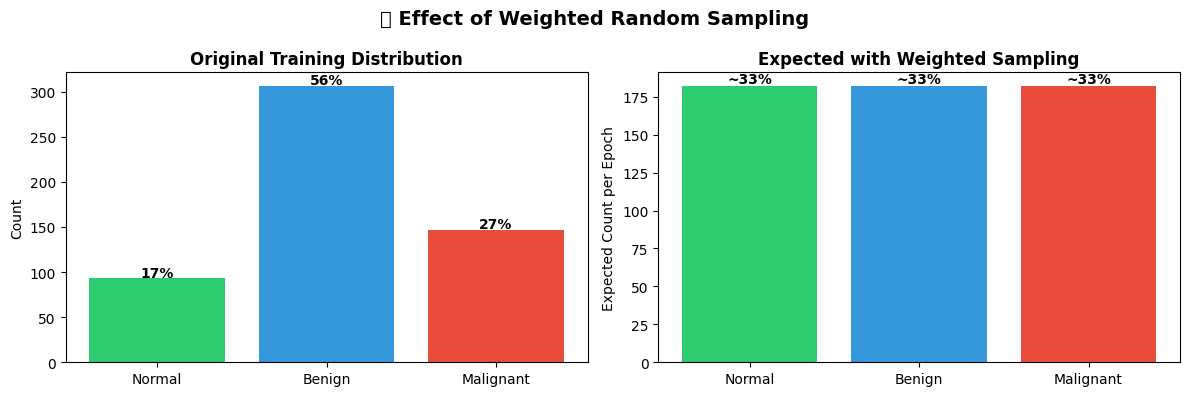

📊 Saved: weighted_sampling_effect.png


In [ ]:
# ============================================
# VISUALIZE: BEFORE vs AFTER WEIGHTED SAMPLING
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
orig_counts = train_df['class'].value_counts()
axes[0].bar(['Normal', 'Benign', 'Malignant'],
            [orig_counts['normal'], orig_counts['benign'], orig_counts['malignant']],
            color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Original Training Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (cls, count) in enumerate(zip(['normal', 'benign', 'malignant'],
                                      [orig_counts['normal'], orig_counts['benign'], orig_counts['malignant']])):
    pct = count / len(train_df) * 100
    axes[0].text(i, count + 2, f'{pct:.0f}%', ha='center', fontweight='bold')

# Expected distribution with weighted sampling (approximately equal)
expected_per_class = len(train_df) / 3
axes[1].bar(['Normal', 'Benign', 'Malignant'],
            [expected_per_class, expected_per_class, expected_per_class],
            color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Expected with Weighted Sampling', fontweight='bold')
axes[1].set_ylabel('Expected Count per Epoch')
for i in range(3):
    axes[1].text(i, expected_per_class + 2, '~33%', ha='center', fontweight='bold')

plt.suptitle('🐧 Effect of Weighted Random Sampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weighted_sampling_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: weighted_sampling_effect.png")

### 🐧💡 Insight: Double Protection Against Imbalance!

We now have TWO mechanisms working together:

1. **WeightedRandomSampler** → Balanced batches during training
   - Model sees each class roughly equally often
   - Normal class (minority) gets sampled ~3x more frequently

2. **Class Weights in Loss** → Penalize minority class errors more
   - Even if model sees equal samples, mistakes on Normal cost more
   - Forces model to pay attention to minority class patterns

This "belt and suspenders" approach is especially important for medical imaging where missing a case (false negative) can be serious! 🏥

In [ ]:
# ============================================
# CREATE FINAL DATALOADERS
# Train: with weighted sampler (balanced batches)
# Val/Test: no sampler (true distribution for fair eval)
# ============================================

BATCH_SIZE = 32
NUM_WORKERS = 2  # Parallel data loading

# Training loader WITH weighted sampler
# Note: when using sampler, don't use shuffle=True
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,  # Balanced sampling!
    num_workers=NUM_WORKERS
)

# Validation loader - NO sampler, we want true distribution
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# Test loader - NO sampler, we want true distribution
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("🐧 DATALOADERS CREATED")
print("=" * 45)
print(f"Batch size: {BATCH_SIZE}")
print(f"\nTrain: {len(train_loader)} batches (with WeightedRandomSampler)")
print(f"Val:   {len(val_loader)} batches (original distribution)")
print(f"Test:  {len(test_loader)} batches (original distribution)")
print("\n💡 Note: Val/Test use original distribution for fair evaluation!")

🐧 DATALOADERS CREATED
Batch size: 32

Train: 18 batches (with WeightedRandomSampler)
Val:   4 batches (original distribution)
Test:  4 batches (original distribution)

💡 Note: Val/Test use original distribution for fair evaluation!


---

## 7. 📊 Radiomics Feature Extraction

🐧 Time for something cool! **Radiomics** extracts quantitative features from medical images.

💡 These features capture:
- **Shape** — lesion geometry (area, perimeter, circularity)
- **Texture** — pixel patterns (contrast, homogeneity, entropy)
- **Intensity** — statistical measures (mean, std, skewness)

We'll use these for our **tabular models** (RF, XGBoost, etc.)

In [ ]:
# ============================================
# RADIOMICS FEATURE EXTRACTION SETUP
# ============================================

print("🐧 Setting up radiomics extractor...")

# Initialize extractor with specific feature classes
extractor = featureextractor.RadiomicsFeatureExtractor()

# Enable specific feature classes
extractor.enableFeatureClassByName('firstorder')  # Intensity statistics
extractor.enableFeatureClassByName('shape2D')     # Shape features (2D)
extractor.enableFeatureClassByName('glcm')        # Gray Level Co-occurrence Matrix
extractor.enableFeatureClassByName('glrlm')       # Gray Level Run Length Matrix

print("✅ Extractor configured!")
print("   Features: firstorder, shape2D, glcm, glrlm")

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}


🐧 Setting up radiomics extractor...
✅ Extractor configured!
   Features: firstorder, shape2D, glcm, glrlm


In [ ]:
def extract_radiomics_features(image_path, mask_path):
    """
    Extract radiomics features from image using mask.

    Args:
        image_path: Path to the ultrasound image
        mask_path: Path to the segmentation mask

    Returns:
        dict of features or None if extraction fails
    """
    try:
        # Load as SimpleITK images (required by pyradiomics)
        image = sitk.ReadImage(image_path, sitk.sitkUInt8)
        mask = sitk.ReadImage(mask_path, sitk.sitkUInt8)

        # Check if mask has content (not all zeros)
        mask_array = sitk.GetArrayFromImage(mask)
        if mask_array.max() == 0:
            return None  # Empty mask - skip

        # Binarize mask (ensure 0 and 1 only)
        mask = sitk.BinaryThreshold(mask, lowerThreshold=1, upperThreshold=255,
                                    insideValue=1, outsideValue=0)

        # Extract features
        features = extractor.execute(image, mask)

        # Filter to only numeric features (skip diagnostics metadata)
        feature_dict = {}
        for key, val in features.items():
            if not key.startswith('diagnostics'):
                try:
                    feature_dict[key] = float(val)
                except:
                    pass

        return feature_dict

    except Exception as e:
        return None

print("✅ Feature extraction function ready!")

✅ Feature extraction function ready!


In [ ]:
# ============================================
# EXTRACT FEATURES FOR ALL IMAGES
# This takes a few minutes!
# radiomics for the wiiiin!
# ============================================

print("🐧 Extracting radiomics features...")
print("   (This takes 3-5 minutes, grab a coffee! ☕)\n")

# Process images with masks that have content (benign & malignant)
# Normal masks are empty, so we skip those
mask_df = df_all[df_all['has_mask'] == True].copy()

all_features = []
success_count = 0
skip_count = 0

for idx, row in mask_df.iterrows():
    features = extract_radiomics_features(row['image_path'], row['mask_path'])

    if features:
        # Add metadata
        features['image_path'] = row['image_path']
        features['class'] = row['class']
        features['class_encoded'] = row['class_encoded']
        features['split'] = row['split']
        all_features.append(features)
        success_count += 1
    else:
        skip_count += 1

    # Progress update every 100 images
    if (success_count + skip_count) % 100 == 0:
        print(f"   Processed {success_count + skip_count} images ({success_count} successful, {skip_count} skipped)...")

# Create DataFrame
radiomics_df = pd.DataFrame(all_features)

print(f"\n✅ Extraction complete!")
print(f"   Successful: {len(radiomics_df)} images")
print(f"   Skipped (empty masks): {skip_count} images")
print(f"   Features extracted: {len(radiomics_df.columns) - 4}")

INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask


🐧 Extracting radiomics features...
   (This takes 3-5 minutes, grab a coffee! ☕)



Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" 

   Processed 100 images (86 successful, 14 skipped)...


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" 

...

   Processed 600 images (497 successful, 103 skipped)...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radi

   Processed 700 images (578 successful, 122 skipped)...


INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Foun


✅ Extraction complete!
   Successful: 645 images
   Skipped (empty masks): 135 images
   Features extracted: 102


In [ ]:
# ============================================
# INSPECT RADIOMICS FEATURES
# ============================================

print("🐧 RADIOMICS FEATURE SUMMARY")
print("=" * 50)

# Get feature columns (exclude metadata)
feature_cols = [c for c in radiomics_df.columns
                if c not in ['image_path', 'class', 'class_encoded', 'split']]

print(f"Total features: {len(feature_cols)}")
print(f"\nFeature categories:")

# Count by category
categories = {}
for col in feature_cols:
    parts = col.split('_')
    if len(parts) > 1:
        cat = parts[1]
    else:
        cat = 'other'
    categories[cat] = categories.get(cat, 0) + 1

for cat, count in sorted(categories.items()):
    print(f"   {cat}: {count} features")

print(f"\nSample feature names:")
for f in feature_cols[:5]:
    print(f"   • {f}")

🐧 RADIOMICS FEATURE SUMMARY
Total features: 102

Feature categories:
   firstorder: 18 features
   glcm: 24 features
   gldm: 14 features
   glrlm: 16 features
   glszm: 16 features
   ngtdm: 5 features
   shape2D: 9 features

Sample feature names:
   • original_shape2D_Elongation
   • original_shape2D_MajorAxisLength
   • original_shape2D_MaximumDiameter
   • original_shape2D_MeshSurface
   • original_shape2D_MinorAxisLength


In [ ]:
# ============================================
# CLASS DISTRIBUTION IN RADIOMICS DATA
# ============================================

print("🐧 RADIOMICS DATA CLASS DISTRIBUTION")
print("=" * 40)
print(radiomics_df['class'].value_counts())
print(f"\n💡 Note: Normal class may have fewer samples")
print(f"   (their masks are often empty)")

🐧 RADIOMICS DATA CLASS DISTRIBUTION
class
benign       437
malignant    208
Name: count, dtype: int64

💡 Note: Normal class may have fewer samples
   (their masks are often empty)


In [ ]:
# ============================================
# SAVE RADIOMICS FEATURES
# ============================================

radiomics_path = PROCESSED_DIR / 'radiomics_features.csv'
radiomics_df.to_csv(radiomics_path, index=False)
print(f"💾 Saved: radiomics_features.csv")
print(f"   Shape: {radiomics_df.shape}")

💾 Saved: radiomics_features.csv
   Shape: (645, 106)


### 🐧💡 Insight: Understanding Radiomics Features

We extracted **100+ quantitative features** that capture patterns beyond what the human eye can easily measure. Here's what each category means:

---

#### **Firstorder** — Basic Pixel Statistics
Simple math on pixel values, ignoring where they are in the image:
- **Mean**: Average brightness
- **Std**: How much brightness varies
- **Skewness**: Is the histogram tilted left or right?
- **Kurtosis**: Are pixel values concentrated in center or spread to extremes?
- **Entropy**: How "random" or unpredictable are pixel values? (high = complex texture)

*Think of it as: "Describe this image using only a histogram"*

---

#### **Shape2D** — Lesion Geometry
Measurements from the mask contour:
- **Area**: How big is the lesion (pixel count)
- **Perimeter**: Length of the boundary
- **Circularity**: How round? (circle = 1, irregular = lower)
- **Elongation**: How stretched? (square = 1, elongated = higher)

*Think of it as: "Describe the lesion's shape without looking inside it"*

---

#### **GLCM (Gray Level Co-occurrence Matrix)** — Texture from Pixel Pairs
Analyzes how often pairs of pixel values appear next to each other:
- **Contrast**: Intensity difference between neighboring pixels (high = sharp edges)
- **Homogeneity**: How similar are neighboring pixels? (high = smooth texture)
- **Correlation**: Are pixel patterns predictable/linear?
- **Energy**: How repetitive is the texture? (high = uniform, low = chaotic)

*Think of it as: "How does each pixel relate to its neighbor?"*

---

#### **GLRLM (Gray Level Run Length Matrix)** — Texture from Pixel "Runs"
Analyzes consecutive pixels of the same intensity (runs):
- **Short runs**: Many small groups of same-intensity pixels → fine/grainy texture
- **Long runs**: Large stretches of same intensity → smooth/uniform regions

*Think of it as: "How long do same-colored streaks continue?"*

---

#### Why These Matter for Breast Ultrasound

| Feature Type | What it might detect |
|--------------|---------------------|
| **Firstorder** | Malignant lesions often have different intensity distributions |
| **Shape2D** | Malignant = irregular borders; Benign = smooth, round |
| **GLCM** | Malignant = heterogeneous texture; Benign = homogeneous |
| **GLRLM** | Malignant = chaotic patterns; Benign = uniform runs |

These features will power my tabular models (Random Forest, XGBoost, etc.) — a great complement to the CNNs!

---

## 8. 📦 Prepare Tabular Data for Sklearn Models

In [ ]:
# ============================================
# PREPARE TABULAR TRAIN/VAL/TEST
# Scale features for sklearn models
# ============================================

# Get feature columns (exclude metadata)
feature_cols = [c for c in radiomics_df.columns
                if c not in ['image_path', 'class', 'class_encoded', 'split']]

# Split by split column
train_rad = radiomics_df[radiomics_df['split'] == 'train']
val_rad = radiomics_df[radiomics_df['split'] == 'val']
test_rad = radiomics_df[radiomics_df['split'] == 'test']

# Extract X (features) and y (labels)
X_train = train_rad[feature_cols].values
y_train = train_rad['class_encoded'].values

X_val = val_rad[feature_cols].values
y_val = val_rad['class_encoded'].values

X_test = test_rad[feature_cols].values
y_test = test_rad['class_encoded'].values

# Handle NaN and Inf values (can occur in some radiomics features)
X_train = np.nan_to_num(X_train, nan=0, posinf=0, neginf=0)
X_val = np.nan_to_num(X_val, nan=0, posinf=0, neginf=0)
X_test = np.nan_to_num(X_test, nan=0, posinf=0, neginf=0)

# Scale features (important for SVM, MLP, etc.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train only!
X_val_scaled = scaler.transform(X_val)          # Transform val
X_test_scaled = scaler.transform(X_test)        # Transform test

print("🐧 TABULAR DATA READY")
print("=" * 40)
print(f"Features: {len(feature_cols)}")
print(f"Train: {X_train_scaled.shape} (y: {y_train.shape})")
print(f"Val:   {X_val_scaled.shape} (y: {y_val.shape})")
print(f"Test:  {X_test_scaled.shape} (y: {y_test.shape})")

🐧 TABULAR DATA READY
Features: 102
Train: (452, 102) (y: (452,))
Val:   (97, 102) (y: (97,))
Test:  (96, 102) (y: (96,))


In [ ]:
# ============================================
# SAVE SCALER AND FEATURE NAMES
# ============================================

import joblib

joblib.dump(scaler, MODELS_DIR / 'radiomics_scaler.pkl')
joblib.dump(feature_cols, MODELS_DIR / 'radiomics_feature_names.pkl')

print("💾 Saved: radiomics_scaler.pkl")
print("💾 Saved: radiomics_feature_names.pkl")

💾 Saved: radiomics_scaler.pkl
💾 Saved: radiomics_feature_names.pkl


---

## 9. 💾 Save Everything

In [ ]:
# ============================================
# SAVE CLASS WEIGHTS FOR TRAINING
# ============================================

torch.save(class_weights_tensor, MODELS_DIR / 'class_weights.pt')
print("💾 Saved: class_weights.pt")

# Save sampler weights too (for recreating sampler)
torch.save(sample_weights, MODELS_DIR / 'sample_weights.pt')
print("💾 Saved: sample_weights.pt")

💾 Saved: class_weights.pt
💾 Saved: sample_weights.pt


In [ ]:
# ============================================
# SAVE PREPROCESSING CONFIG
# ============================================

import json

preprocess_config = {
    'img_size': IMG_SIZE,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
    'batch_size': BATCH_SIZE,
    'random_seed': RANDOM_SEED,
    'class_names': ['normal', 'benign', 'malignant'],
    'class_weights': class_weights.tolist(),
    'num_radiomics_features': len(feature_cols)
}

with open(PROCESSED_DIR / 'preprocess_config.json', 'w') as f:
    json.dump(preprocess_config, f, indent=2)

print("💾 Saved: preprocess_config.json")

💾 Saved: preprocess_config.json


In [ ]:
# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("🐧✨ FEATURE ENGINEERING COMPLETE! ✨🐧")
print("="*60)

print("\n📁 Files saved to data/processed/:")
print("   • train.csv, val.csv, test.csv")
print("   • all_splits.csv")
print("   • preprocess_config.json")
print("   • radiomics_features.csv")

print("\n📁 Files saved to models/:")
print("   • class_weights.pt")
print("   • sample_weights.pt")
print("   • radiomics_scaler.pkl")
print("   • radiomics_feature_names.pkl")

print("\n📊 Figures saved to reports/figures/:")
print("   • data_splits.png")
print("   • augmentation_examples.png")
print("   • weighted_sampling_effect.png")

print("\n" + "="*60)
print("🚀 NEXT: 03_model_training.ipynb")
print("   → Train 5 CNN models")
print("   → Train 5 tabular models")
print("   → Compare all 10 models!")
print("="*60)


🐧✨ FEATURE ENGINEERING COMPLETE! ✨🐧

📁 Files saved to data/processed/:
   • train.csv, val.csv, test.csv
   • all_splits.csv
   • preprocess_config.json
   • radiomics_features.csv

📁 Files saved to models/:
   • class_weights.pt
   • sample_weights.pt
   • radiomics_scaler.pkl
   • radiomics_feature_names.pkl

📊 Figures saved to reports/figures/:
   • data_splits.png
   • augmentation_examples.png
   • weighted_sampling_effect.png

🚀 NEXT: 03_model_training.ipynb
   → Train 5 CNN models
   → Train 5 tabular models
   → Compare all 10 models!


---

## 📝 Summary

### 🐧 What We Built!

| Component | Details |
|-----------|--------|
| **Data Splits** | Train 70%, Val 15%, Test 15% (stratified) |
| **Image Pipeline** | Resize 224x224, RGB, ImageNet normalization |
| **Augmentations** | Flip, rotation, color jitter (training only) |
| **Class Weights** | Inverse frequency for loss function |
| **WeightedRandomSampler** | Balanced batches during training |
| **Radiomics** | 100+ features per image |
| **Tabular Data** | Scaled features ready for sklearn |

### 💡 Key Decisions

1. **Stratified splits** → Maintain class proportions in all sets
2. **WeightedRandomSampler** → Balanced batches (better than simple oversampling!)
3. **Class weights** → Double protection for imbalance in loss
4. **Augmentation only on training** → Fair evaluation on val/test
5. **ImageNet normalization** → Transfer learning ready

### 🐧💡 Why Our Imbalance Strategy Works

We use **WeightedRandomSampler** instead of:
- ❌ Simple oversampling (risk of overfitting to duplicates)
- ❌ Undersampling (loses valuable data)
- ❌ SMOTE (doesn't work for images)

**WeightedRandomSampler** gives us:
- ✅ All data used (no loss)
- ✅ Balanced batches
- ✅ Different combinations each epoch
- ✅ Works great with augmentation

---

**Ready for model training!** 🚀

---
### End of Notebook
---